# Range strangle (no fallback, no VWAP)

Single-regime short-strangle strategy. No VWAP, no skew.

**Entry:** trailing `range_win`-second spot range < `range_bps_max` (15 bps) — market is calm. Short the two strikes that bracket spot most tightly.

**Pyramid:** 4 groups (1+2+3+4 = 10 lots/side) at 2-min intervals. Gate to add each group: range over the last 2 min is still below `range_bps_max`. If the market wakes up mid-build the pyramid freezes and we hold to an exit.

**Risk exits (margin-anchored):** profit-take at 2% of margin · fixed stop at 1% loss · trailing (arms at 1.5%, give-back 1%) · 2-hr time backstop · daily stop at 1% of total margin.

**Flat when:** range condition not met. No fallback position.


In [19]:
from engine import BirdsEye
from strategies.range_strangle_nofallback import RangeStrangleNoFallback

be = BirdsEye(
    data_dir          = "/mnt/INTERNAL_DATA/INTERN_DATA/OPRA_DATA_1SEC/0DTE/SPY",
    strategy_cls      = RangeStrangleNoFallback,
    index             = "SPY",
    lot_size          = 100,
    starting_cash     = 1_000_000.0,
    margin_per_lot    = 10_000.0,
    fields            = ("spot", "atm_strike",
                         "ce_bid_0", "ce_ask_0", "pe_bid_0", "pe_ask_0"),
    strategy_kwargs   = {
        "max_lots":         10,
        "lots":             10,
        "range_bps_max":    15.0,       # trailing range ceiling to trigger entry (bps)
        "range_win":        900,        # 15-min window for range alpha + warm-up
        "pyramid_schedule": (1, 2, 3, 4),
        "group_interval":   2 * 60,     # 2 min between pyramid groups
        "tight_hold":       2 * 60 * 60,
        "margin_per_lot":   10_000.0,   # must match BirdsEye margin_per_lot
        # --- per-trade risk exits (anchored to margin deployed) ---
        "profit_take_frac": 0.02,       # take profit at 2% of margin
        "stop_loss_frac":   0.001,       # cut at 1% of margin loss
        "trail_arm_frac":   0.015,      # trailing arms once up 1.5% of margin
        "trail_frac":       0.01,      # give back 1.0% of margin from peak
        # --- daily stop ---
        "day_stop_frac":    0.005,       # halt + exit if day PnL <= -1% of total margin
        # "profit_target": 500.0, "stop_loss_abs": 250.0, "trail_stop": 150.0,
        "quote_persist":    60,
    },
    cost_kwargs       = {"txn_cost_per_lot": 0.85},
    n_workers         = 40,
    collect_perseclog = True,
    # days=["20240102", "20240104"],
)
res = be.run()


In [20]:
import matplotlib.pyplot as plt

DAY = res.days[0]   # pick any day from the run

# 1. per-day summary
print("=== per-day summary ===")
display(res.summary)


=== per-day summary ===


,fills,gross($),costs($),net($)
day,,,,
20240102,56,-190.0,123.0,-313.0
20240104,112,-785.0,232.0,-1017.0
20240105,88,-263.0,180.4,-443.4
20240109,112,-843.0,245.0,-1088.0
20240110,84,573.0,164.0,409.0
...,...,...,...,...
20250804,56,614.0,113.0,501.0
20250806,94,235.0,223.0,12.0
20250807,84,162.0,186.0,-24.0


In [21]:
def display_stats(stats: dict):
    from IPython.display import display, HTML

    def fmt(k, v):
        if isinstance(v, float):
            if "pct" in k or "cagr" in k or "calmar" in k:
                color = "green" if v > 0 else "red"
                return f'<span style="color:{color}">{v:+.2f}%</span>'
            if "pnl" in k or "day" in k or "win" in k or "loss" in k or "cost" in k:
                color = "green" if v > 0 else ("red" if v < 0 else "inherit")
                return f'<span style="color:{color}">${v:+,.2f}</span>'
            return f"{v:.4f}"
        if isinstance(v, int):
            return f"{v:,}"
        return str(v)

    rows = "".join(
        f"<tr><td style='padding:4px 16px 4px 0;color:gray;font-size:13px'>{k}</td>"
        f"<td style='padding:4px 0;font-size:13px;font-weight:500'>{fmt(k,v)}</td></tr>"
        for k, v in stats.items()
    )
    display(HTML(f"<table style='border-collapse:collapse'>{rows}</table>"))

display_stats(res.stats())


n_days,277
total_pnl,"$-16,856.40"
avg_day,$-60.85
pct_pos_days,+0.46%
pct_neg_days,+0.48%
avg_win,$+402.74
avg_loss,$-507.50
best_day,"$+1,267.00"
worst_day,"$-1,173.00"
cagr_gross,+267.46%
maxDD_gross,33.8550


In [22]:
# trade ledger
led = res.tradelog
print(f"=== trade ledger: {len(led)} fills ===")
display(led.head(10))
print("\nfills by signal:")
display(led.groupby("signal")["exe_cost"].agg(["count","sum"]).round(2))


=== trade ledger: 20222 fills ===


,day,timestamp,strike,opt_type,action,lots,fill_price,txn_cost,brokerage,spread_cost,...,alpha_range_win_bps,alpha_day_stop_hit,alpha_day_pnl,alpha_upnl,alpha_margin,alpha_group,alpha_t_ce,alpha_t_pe,alpha_t_ok,alpha_tight_legs_ok
0,20240102,19:00:00,472.0,CE,SELL,1.0,0.74,0.85,0.0,0.5,...,5.73,0.0,0.0,0.0,0.0,0.0,472.0,471.0,1.0,1.0
1,20240102,19:00:00,471.0,PE,SELL,1.0,0.74,0.85,0.0,0.5,...,5.73,0.0,0.0,0.0,0.0,0.0,472.0,471.0,1.0,1.0
2,20240102,19:00:00,472.0,CE,SELL,2.0,0.76,1.70,0.0,1.0,...,3.65,0.0,1.3,4.0,20000.0,1.0,472.0,471.0,1.0,1.0
3,20240102,19:00:00,471.0,PE,SELL,2.0,0.70,1.70,0.0,1.0,...,3.65,0.0,1.3,4.0,20000.0,1.0,472.0,471.0,1.0,1.0
4,20240102,19:00:00,472.0,CE,SELL,3.0,0.84,2.55,0.0,1.5,...,9.54,0.0,4.9,13.0,60000.0,2.0,472.0,471.0,1.0,1.0
5,20240102,19:00:00,471.0,PE,SELL,3.0,0.56,2.55,0.0,1.5,...,9.54,0.0,4.9,13.0,60000.0,2.0,472.0,471.0,1.0,1.0
6,20240102,19:00:00,472.0,CE,SELL,4.0,1.04,3.40,0.0,2.0,...,10.69,0.0,-36.2,-20.0,120000.0,3.0,473.0,472.0,1.0,1.0
7,20240102,19:00:00,471.0,PE,SELL,4.0,0.42,3.40,0.0,2.0,...,10.69,0.0,-36.2,-20.0,120000.0,3.0,473.0,472.0,1.0,1.0
8,20240102,19:00:00,472.0,CE,BUY,1.0,1.31,0.85,0.0,1.0,...,5.71,0.0,-2.0,25.0,200000.0,4.0,474.0,473.0,1.0,1.0
9,20240102,19:00:00,471.0,PE,BUY,1.0,0.12,0.85,0.0,0.5,...,5.71,0.0,-2.0,25.0,200000.0,4.0,474.0,473.0,1.0,1.0



fills by signal:


,count,sum
signal,,
,142,1979.7
calm_range,1598,2261.8
day_stop,344,518.9
stop_loss,8178,14699.3
tight_add,4592,19134.4
tight_done,5368,7661.3


=== per-second log 20240102: 19773 rows ===


,timestamp,spot,atm,state,sec,range_bps,range_win_bps,day_stop_hit,day_pnl,upnl,margin,group,t_ce,t_pe,t_ok,tight_legs_ok
2000,2004,472.52,473.0,TIGHT_HOLD,2004.0,26.26,4.89,0.0,-107.0,-80.0,200000.0,4.0,473.0,472.0,1.0,1.0
2001,2005,472.53,473.0,TIGHT_HOLD,2005.0,26.26,4.68,0.0,-107.0,-80.0,200000.0,4.0,473.0,472.0,1.0,1.0
2002,2006,472.53,473.0,TIGHT_HOLD,2006.0,26.26,4.68,0.0,-107.0,-80.0,200000.0,4.0,473.0,472.0,1.0,1.0
2003,2007,472.55,473.0,TIGHT_HOLD,2007.0,26.26,4.68,0.0,-117.0,-90.0,200000.0,4.0,473.0,472.0,1.0,1.0
2004,2008,472.56,473.0,TIGHT_HOLD,2008.0,26.26,4.68,0.0,-117.0,-90.0,200000.0,4.0,473.0,472.0,1.0,1.0


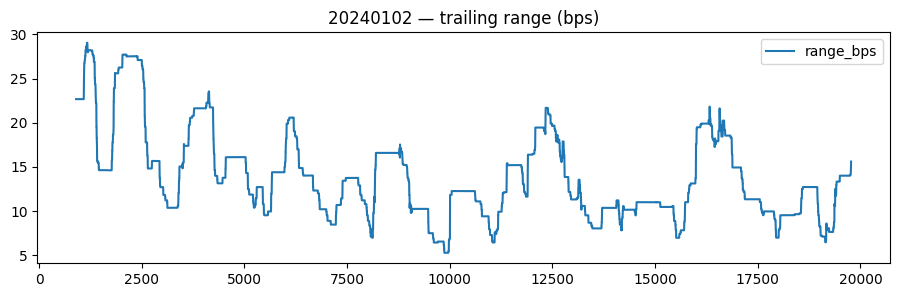

In [23]:
sl = res.perseclog(DAY)
print(f"=== per-second log {DAY}: {len(sl)} rows ===")
display(sl.iloc[2000:2005])

import matplotlib.pyplot as plt
sl.plot(y=["range_bps"], figsize=(11, 3), title=f"{DAY} — trailing range (bps)"); plt.show()


array([<Axes: title={'center': 'net P&L (after costs)'}, ylabel='cum P&L ($)'>,
       <Axes: title={'center': 'mid-only P&L (no costs)'}, xlabel='days', ylabel='cum P&L ($)'>],
      dtype=object)

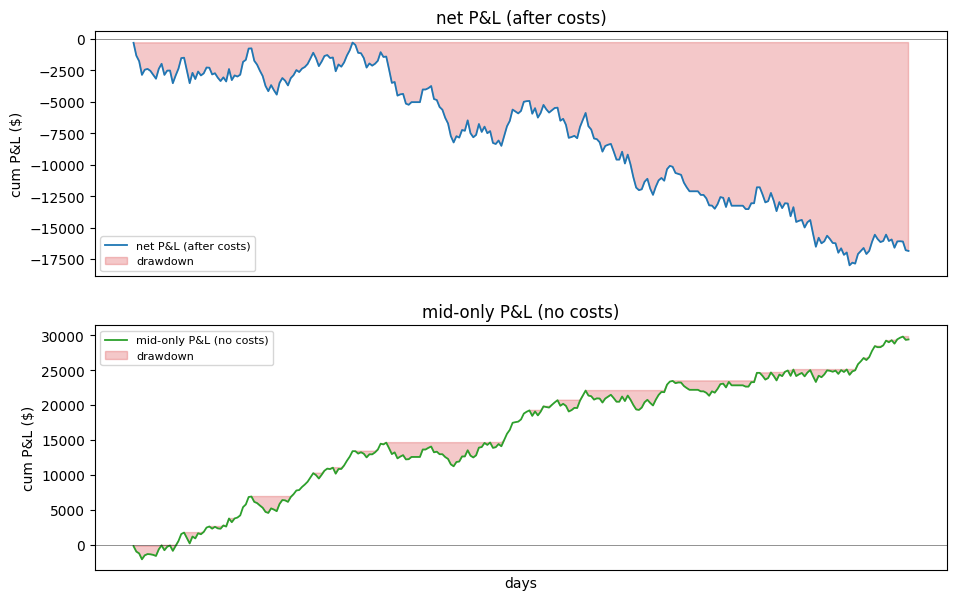

In [24]:
from engine.plots import plot_equity
plot_equity(res)


In [25]:
# ============================================================================
# PnL statistics by TRADE TYPE (one episode = one round trip)
#   tight : calm_range  +  tight_add(s)  +  stop (profit_take/stop_loss/trailing/tight_done/day_stop)
# mid-p PnL uses ONLY fill prices (SELL = +price, BUY = -price) x lots x lot_size.
# t-cost is the ledger's exe_cost (txn + brokerage + spread).
# ============================================================================
import numpy as np
import pandas as pd

_OPENERS = {"calm_range": "tight"}
_ADDERS  = {"tight_add": "tight"}
_CLOSERS = {"profit_take": "skew", "stop_loss": "skew", "trailing": "skew",
            "tight_done": "tight"}


def _segment(df):
    df   = df.reset_index(drop=True)
    sigs = df["signal"].tolist()
    runs, start = [], 0
    for k in range(1, len(df) + 1):
        if k == len(df) or sigs[k] != sigs[start]:
            runs.append(df.iloc[start:k]); start = k

    eps, cur = [], None
    for run in runs:
        sig = run["signal"].iloc[0]
        if sig in _OPENERS:
            if cur is not None: eps.append(cur)
            cur = {"type": _OPENERS[sig], "fills": [run]}
        elif cur is not None:
            cur["fills"].append(run)
            if sig in _CLOSERS or sig in ("eod_square_off", "day_stop"):
                eps.append(cur); cur = None
        else:
            t = _ADDERS.get(sig) or _CLOSERS.get(sig) or "unknown"
            cur = {"type": t, "fills": [run]}
            if sig in _CLOSERS or sig in ("eod_square_off", "day_stop"):
                eps.append(cur); cur = None
    if cur is not None: eps.append(cur)
    for e in eps: e["fills"] = pd.concat(e["fills"], ignore_index=True)
    return eps


def _episode_stats(ep, lot_size):
    f      = ep["fills"]
    sign   = np.where(f["action"] == "SELL", 1.0, -1.0)
    midp   = float((sign * f["fill_price"] * f["lots"] * lot_size).sum())
    tcost  = float(f["exe_cost"].sum())
    openl  = float(f.loc[f["action"] == "SELL", "lots"].sum())
    net_pos= float(np.where(f["action"] == "BUY", f["lots"], -f["lots"]).sum())
    return {"type": ep["type"], "n_fills": len(f), "midp_pnl": midp, "tcost": tcost,
            "net_pnl": midp - tcost, "open_lots": openl, "flat": abs(net_pos) < 1e-9}


def trade_pnl_stats(led, lot_size, verbose=True):
    """Per-trade-type PnL stats. Returns (per_type_table, per_trade_table)."""
    if led is None or len(led) == 0:
        if verbose: print("empty ledger"); return pd.DataFrame(), pd.DataFrame()
    eps = []
    for _, g in led.groupby("day", sort=True):
        eps += _segment(g)
    per_trade = pd.DataFrame([_episode_stats(e, lot_size) for e in eps])
    order = ["tight"]
    agg = per_trade.groupby("type").agg(
        trades=("type","size"), midp_pnl=("midp_pnl","sum"),
        tcost=("tcost","sum"), net_pnl=("net_pnl","sum"), open_lots=("open_lots","sum"))
    agg = agg.reindex([t for t in order if t in agg.index]
                      + [t for t in agg.index if t not in order])
    agg["midp_per_lot"]   = agg["midp_pnl"] / agg["open_lots"].replace(0, np.nan)
    agg["midp_per_trade"] = agg["midp_pnl"] / agg["trades"]
    agg["tcost_per_trade"]= agg["tcost"]    / agg["trades"]
    total = pd.Series({
        "trades": agg["trades"].sum(), "midp_pnl": agg["midp_pnl"].sum(),
        "tcost": agg["tcost"].sum(), "net_pnl": agg["net_pnl"].sum(),
        "open_lots": agg["open_lots"].sum(),
        "midp_per_lot":    agg["midp_pnl"].sum() / max(agg["open_lots"].sum(), 1e-9),
        "midp_per_trade":  agg["midp_pnl"].sum() / max(agg["trades"].sum(), 1),
        "tcost_per_trade": agg["tcost"].sum()    / max(agg["trades"].sum(), 1),
    }, name="TOTAL")
    table = pd.concat([agg, total.to_frame().T])
    if verbose:
        show = table.copy()
        for c in ["midp_pnl","tcost","net_pnl","midp_per_lot","midp_per_trade","tcost_per_trade"]:
            show[c] = show[c].astype(float).round(2)
        show["trades"]    = show["trades"].astype(int)
        show["open_lots"] = show["open_lots"].astype(float).round(0).astype(int)
        print("=== PnL by trade type (mid-price) ==="); print(show.to_string())
        n_open = int((~per_trade["flat"]).sum())
        if n_open: print(f"\nNote: {n_open} episode(s) not flat.")
        print(f"\nTOTAL NET PnL (after costs):     {table.loc['TOTAL','net_pnl']:,.2f}")
        print(f"TOTAL mid-p PnL (before costs):  {table.loc['TOTAL','midp_pnl']:,.2f}")
        print(f"TOTAL t-costs:                   {table.loc['TOTAL','tcost']:,.2f}")
        print(f"mid-p PnL per opening lot:       {table.loc['TOTAL','midp_per_lot']:,.4f}")
    return table, per_trade


pnl_by_type, pnl_by_trade = trade_pnl_stats(res.tradelog, lot_size=res.cfg.lot_size)


=== PnL by trade type (mid-price) ===
       trades  midp_pnl    tcost  net_pnl  open_lots  midp_per_lot  midp_per_trade  tcost_per_trade
tight     799   28672.0  46255.4 -17583.4      15282          1.88           35.88            57.89
TOTAL     799   28672.0  46255.4 -17583.4      15282          1.88           35.88            57.89

TOTAL NET PnL (after costs):     -17,583.40
TOTAL mid-p PnL (before costs):  28,672.00
TOTAL t-costs:                   46,255.40
mid-p PnL per opening lot:       1.8762
